# AI Tools, Salary & Developer Profile — Stack Overflow Developer Survey 2024 
This notebook is structured and focuses on:

-  **AI tools developers use**(real tool names)
-  **Salary analysis**(cleaned and log-transformed)
- **Work experience**(numeric and grouped)
-  **AI tool adoption and usage patterns**
-  **Salary differences by experience and AI usage**(pivot-based analysis)
-  **Developer profile insights** (languages, roles, countries, job satisfaction)


## 1) Load dataset (auto-detect path)
The code searches for `survey_results_public.csv` inside `/kaggle/input/`.

In [93]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/berkayalan/stack-overflow-annual-developer-survey-2024/survey_results_schema.csv
/kaggle/input/datasets/berkayalan/stack-overflow-annual-developer-survey-2024/2024 Developer Survey.pdf
/kaggle/input/datasets/berkayalan/stack-overflow-annual-developer-survey-2024/survey_results_public.csv


In [94]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
path = "/kaggle/input/datasets/berkayalan/stack-overflow-annual-developer-survey-2024/survey_results_public.csv"

df_raw = pd.read_csv(path, low_memory=False)

print(df_raw.shape)
df_raw.head()


(65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## 2) Select columns (intelligent + consistent)
We keep only what supports the questions.

In [95]:
cols = [
    # Numeric (quantitative)
    "ConvertedCompYearly", "WorkExp",
    # Categorical (qualitative)
    "Country", "JobSat", "DevType",
    "LanguageHaveWorkedWith",
    # AI tools (real tool names)
    "AIToolCurrently Using", "AISearchDevHaveWorkedWith"
]

df = df_raw[cols].copy()
df["UsesAI"] = df["AIToolCurrently Using"].notna()
df.head()


,ConvertedCompYearly,WorkExp,Country,JobSat,DevType,LanguageHaveWorkedWith,AIToolCurrently Using,AISearchDevHaveWorkedWith,UsesAI
0,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,False
1,NaN,17.0,United Kingdom of Great Britain and Northern I...,NaN,"Developer, full-stack",Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,NaN,NaN,False
2,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,Developer Experience,C#,NaN,NaN,False
3,NaN,NaN,Canada,NaN,"Developer, full-stack",C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,Learning about a codebase;Project planning;Wri...,NaN,True
4,NaN,NaN,Norway,NaN,"Developer, full-stack",C++;HTML/CSS;JavaScript;Lua;Python;Rust,NaN,NaN,False


## 3) Missing values (before cleaning)
We show missing count and percentage for transparency.

In [96]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"MissingCount": missing, "Missing%": missing_pct})


,MissingCount,Missing%
ConvertedCompYearly,42002,64.19
JobSat,36311,55.49
WorkExp,35779,54.68
AIToolCurrently Using,30365,46.40
AISearchDevHaveWorkedWith,20984,32.07
Country,6507,9.94
DevType,5992,9.16
LanguageHaveWorkedWith,5692,8.70
UsesAI,0,0.00


## 4. Data Cleaning & Feature Engineering
This section standardizes salary, experience, categorical variables,
and AI tool usage to prepare the data for analysis.

In [97]:
# --- Remove duplicates ---
df = df.drop_duplicates()
# --- Numeric conversion ---
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")
df["WorkExp"] = pd.to_numeric(df["WorkExp"], errors="coerce")
df["JobSat"] = pd.to_numeric(df["JobSat"], errors="coerce")
# --- Remove essential missing values ---
df = df.dropna(subset=["ConvertedCompYearly", "WorkExp"])
# --- Salary cleaning (keep valid positive salaries only) ---
df = df[df["ConvertedCompYearly"] > 0]
# --- Remove extreme salary outliers (top 1%) ---
upper_salary = df["ConvertedCompYearly"].quantile(0.99)
df = df[df["ConvertedCompYearly"] <= upper_salary]
# --- Job satisfaction valid range ---
df = df[df["JobSat"].between(0, 9)]
# --- Valid Work Experience range ---
df = df[(df["WorkExp"] >= 0) & (df["WorkExp"] <= 50)]
# --- Clean text columns ---
text_cols = ["Country", "DevType", "Employment"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()
# --- Clean AI worked-with column ---
df["AISearchDevHaveWorkedWith"] = (
    df["AISearchDevHaveWorkedWith"]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA}))

# =====================================================
# ⚙️ FEATURE ENGINEERING
# =====================================================
# --- Log salary ---
df["Salary_log10"] = np.log10(df["ConvertedCompYearly"])
# --- Main developer type ---
df["DevType_main"] = ( df["DevType"].astype("string").str.split(";").str[0].str.strip())
# --- AI usage flag (current usage) ---
df["AI_User"] = df["AIToolCurrently Using"].notna()
# --- Long format for AI tools ---
ai_tools_long = (
    df["AISearchDevHaveWorkedWith"].dropna().str.split(";").explode().str.strip())
# --- Long format for tools & languages ---
tools_df = (
    df["AIToolCurrently Using"].dropna().astype(str).str.split(";").explode().str.strip())
langs_df = (
    df["LanguageHaveWorkedWith"].dropna().astype(str).str.split(";").explode().str.strip())
# --- Dataset for regression ---
df["WorkExp_num"] = df["WorkExp"]
df_reg = df[["WorkExp_num", "Salary_log10"]].dropna()
# --- Dataset for Job Satisfaction analysis ---
df_js = df[["AI_User", "JobSat"]].dropna()

## 5) Qualitative vs Quantitative columns

In [98]:
cols_qual = ["Country","DevType", "LanguageHaveWorkedWith",
            "AIToolCurrently Using", "AISearchDevHaveWorkedWith"]

cols_quant = ["ConvertedCompYearly", "Salary_log10",  "JobSat", "WorkExp_num"]

notes_map = {
    "Country": "Nominal",
    "DevType": "Multi-select",
    "LanguageHaveWorkedWith": "Multi-select",
    "AIToolCurrently Using": "Text / multi-select",
    "AISearchDevHaveWorkedWith": "Multi-select",
    "ConvertedCompYearly": "Continuous numeric",
    "JobSat": "Ordinal scale (treated as numeric)",
    "Salary_log10": "Log10 transform of salary",
    "WorkExp_num": "Numeric work experience (years) after cleaning"
}

var_types = pd.DataFrame({
    "Variable": cols_qual + cols_quant,
    "Type": (
        ["Qualitative"] * len(cols_qual) +
        ["Quantitative"] * len(cols_quant)
    ),
    "Notes": [notes_map.get(v, "") for v in cols_qual + cols_quant]
})

var_types


,Variable,Type,Notes
0,Country,Qualitative,Nominal
1,DevType,Qualitative,Multi-select
2,LanguageHaveWorkedWith,Qualitative,Multi-select
3,AIToolCurrently Using,Qualitative,Text / multi-select
4,AISearchDevHaveWorkedWith,Qualitative,Multi-select
5,ConvertedCompYearly,Quantitative,Continuous numeric
6,Salary_log10,Quantitative,Log10 transform of salary
7,JobSat,Quantitative,Ordinal scale (treated as numeric)
8,WorkExp_num,Quantitative,Numeric work experience (years) after cleaning


# Part A — Qualitative Analysis (describe → visualize)

In [99]:
df.describe(include=["object", "string"])

,Country,DevType,LanguageHaveWorkedWith,AIToolCurrently Using,AISearchDevHaveWorkedWith,DevType_main
count,14684,14669,14652,9066,11503,14669
unique,153,34,7169,723,1006,34
top,United States of America,"Developer, full-stack",HTML/CSS;JavaScript;TypeScript,Writing code;Debugging and getting help;Search...,ChatGPT,"Developer, full-stack"
freq,2829,5323,272,545,2620,5323


In [100]:
import os
os.makedirs("XMJ-assets", exist_ok=True)

## A1) AI adoption rate

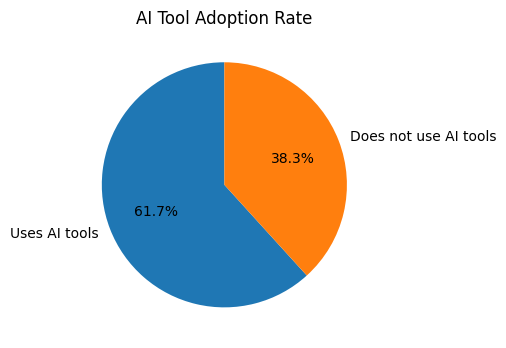

In [101]:
counts = df["AI_User"].value_counts()
plt.figure(figsize=(5,5))
plt.pie([counts.get(True,0), counts.get(False,0)],
        labels=["Uses AI tools", "Does not use AI tools"],
        autopct="%1.1f%%", startangle=90)
plt.title("AI Tool Adoption Rate")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_AI Tool Adoption Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## A2) Top AI tools (REAL tool names) — Top 10

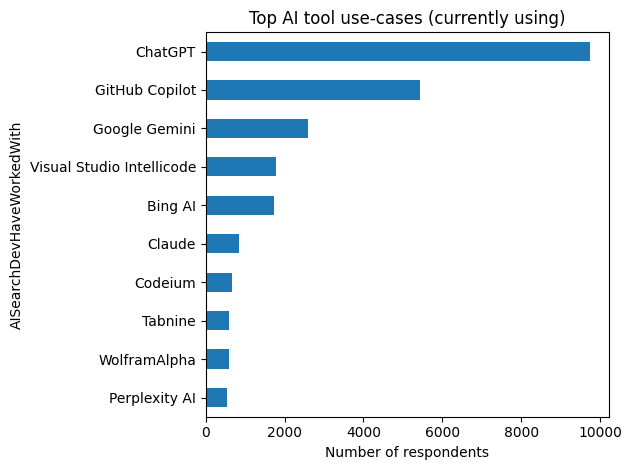

AISearchDevHaveWorkedWith
ChatGPT                      9743
GitHub Copilot               5425
Google Gemini                2596
Visual Studio Intellicode    1783
Bing AI                      1730
Claude                        839
Codeium                       665
Tabnine                       600
WolframAlpha                  587
Perplexity AI                 553
Name: count, dtype: int64

In [102]:

usage_top =ai_tools_long.value_counts().head(10)

usage_top.sort_values().plot(kind="barh")
plt.title("Top AI tool use-cases (currently using)")
plt.xlabel("Number of respondents")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_AI Tool use cases.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
usage_top

## A3) Top for using AI — Top 10

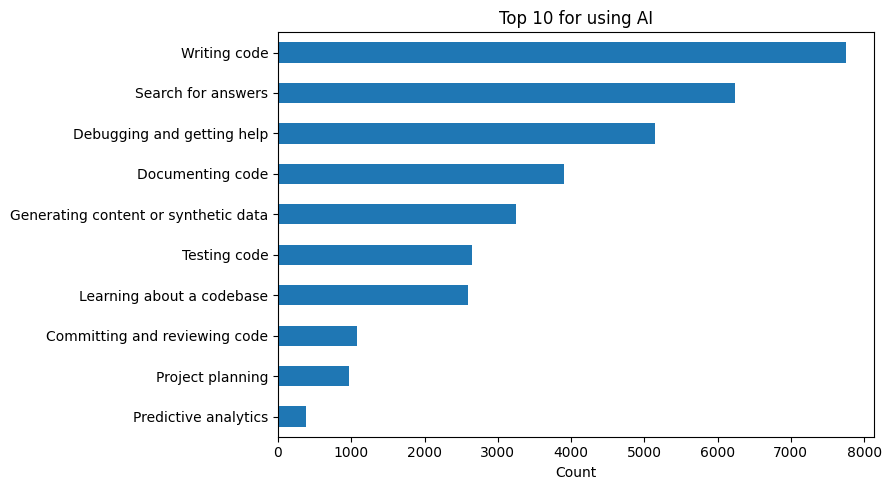

AIToolCurrently Using
Writing code                            7748
Search for answers                      6244
Debugging and getting help              5148
Documenting code                        3905
Generating content or synthetic data    3242
Testing code                            2644
Learning about a codebase               2592
Committing and reviewing code           1072
Project planning                         967
Predictive analytics                     389
Name: count, dtype: int64

In [103]:

top_tools = tools_df.value_counts().head(10)

top_tools.sort_values().plot(kind="barh", figsize=(9,5))
plt.title("Top 10 for using AI")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_top 10 for using ai.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

top_tools

## A4) Top programming languages — Top 10

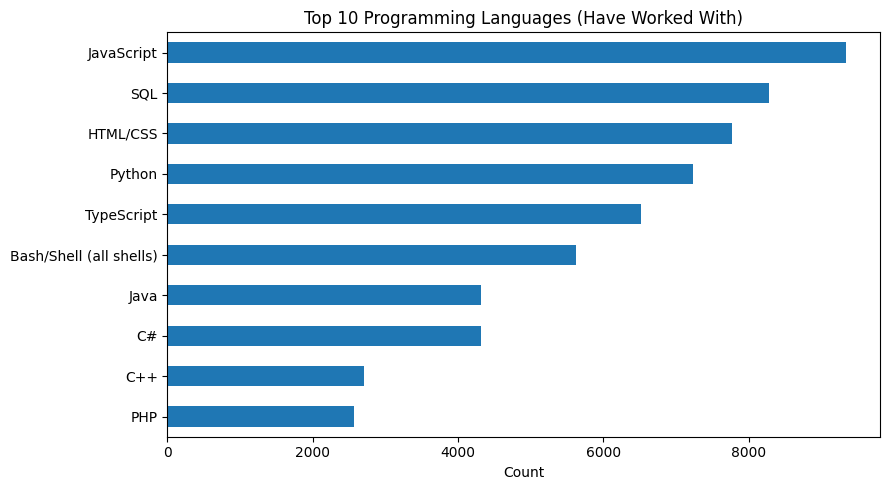

LanguageHaveWorkedWith
JavaScript                 9340
SQL                        8283
HTML/CSS                   7767
Python                     7228
TypeScript                 6517
Bash/Shell (all shells)    5625
C#                         4320
Java                       4320
C++                        2703
PHP                        2569
Name: count, dtype: int64

In [104]:

top_langs = langs_df.value_counts().head(10)

top_langs.sort_values().plot(kind="barh", figsize=(9,5))
plt.title("Top 10 Programming Languages (Have Worked With)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_top 10 pro langue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

top_langs


## A5) Top countries  — Top 10

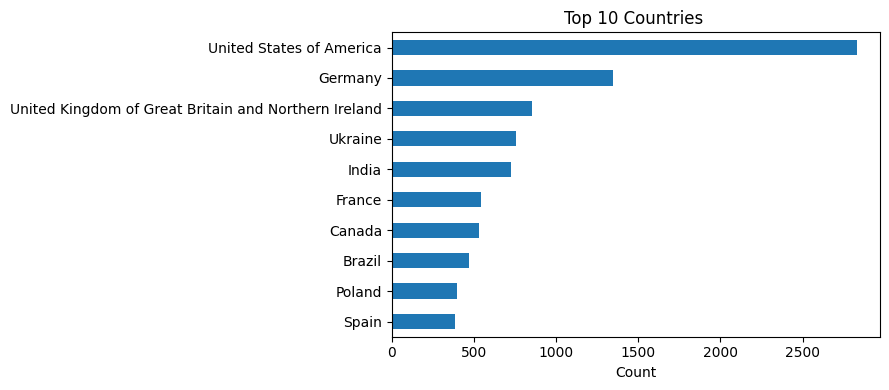

Country
United States of America                                2829
Germany                                                 1347
United Kingdom of Great Britain and Northern Ireland     854
Ukraine                                                  755
India                                                    727
France                                                   543
Canada                                                   528
Brazil                                                   471
Poland                                                   399
Spain                                                    387
Name: count, dtype: Int64

In [105]:
top_countries = df["Country"].value_counts().head(10)

top_countries.sort_values().plot(kind="barh", figsize=(9,4))
plt.title("Top 10 Countries ")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_top 10 countries.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

top_countries


## A6) Job satisfaction — describe + visual

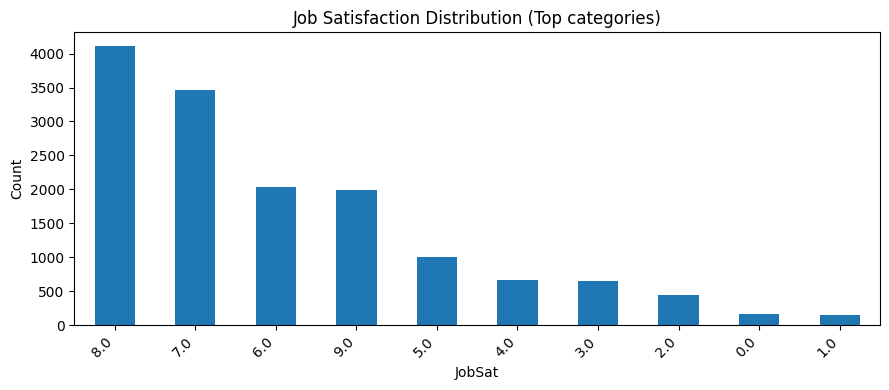

JobSat
8.0    4107
7.0    3468
6.0    2033
9.0    1987
5.0     999
4.0     664
3.0     650
2.0     452
0.0     168
1.0     156
Name: count, dtype: int64

In [106]:
job_counts = df["JobSat"].value_counts().head(10)

plt.figure(figsize=(9,4))
job_counts.plot(kind="bar")
plt.title("Job Satisfaction Distribution (Top categories)")
plt.xlabel("JobSat")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_job satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

job_counts


## A7) Devloper type — Top 10

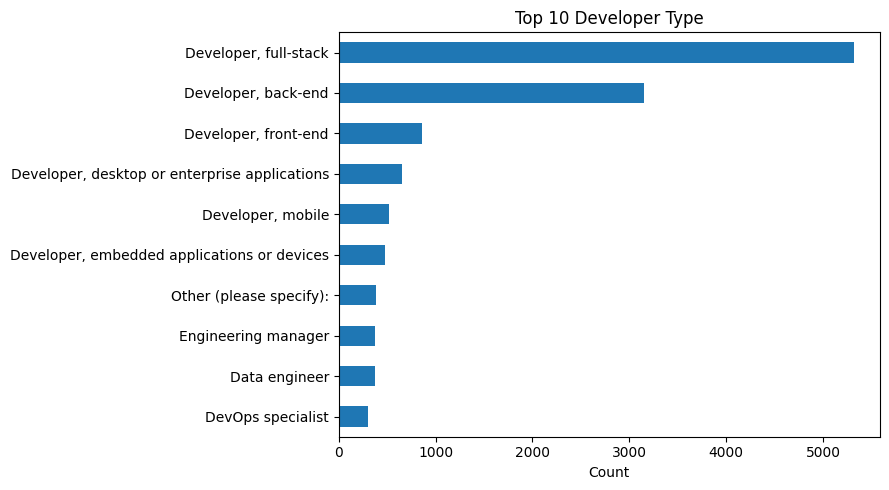

DevType_main
Developer, full-stack                            5323
Developer, back-end                              3157
Developer, front-end                              861
Developer, desktop or enterprise applications     651
Developer, mobile                                 515
Developer, embedded applications or devices       476
Other (please specify):                           381
Engineering manager                               374
Data engineer                                     370
DevOps specialist                                 301
Name: count, dtype: int64

In [107]:

top_tools = df["DevType_main"].value_counts().head(10)

top_tools.sort_values().plot(kind="barh", figsize=(9,5))
plt.title("Top 10 Developer Type")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_top 10 devtype.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

top_tools


# Part B — Quantitative Analysis (describe → visualize)

In [108]:
df[cols_quant].describe()

,ConvertedCompYearly,Salary_log10,JobSat,WorkExp_num
count,14684.000000,14684.000000,14684.000000,14684.000000
mean,77096.939594,4.681834,6.665350,10.924612
std,60140.351682,0.576545,1.986873,8.728016
min,1.000000,0.000000,0.000000,0.000000
25%,32998.750000,4.518497,6.000000,4.000000
50%,64444.000000,4.809182,7.000000,8.000000
75%,105706.000000,5.024100,8.000000,15.000000
max,363465.000000,5.560463,9.000000,50.000000


## B1) Salary —  visual 

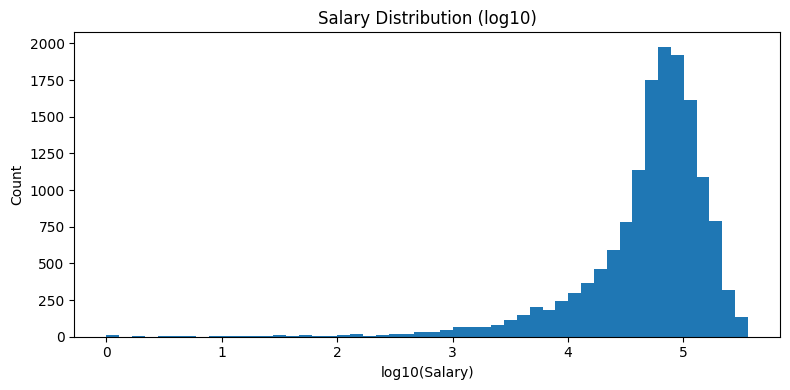

In [109]:

plt.figure(figsize=(8,4))
plt.hist(df["Salary_log10"], bins=50)
plt.title("Salary Distribution (log10)")
plt.xlabel("log10(Salary)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_salaire.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## B2) Experience (WorkExp) —  visual

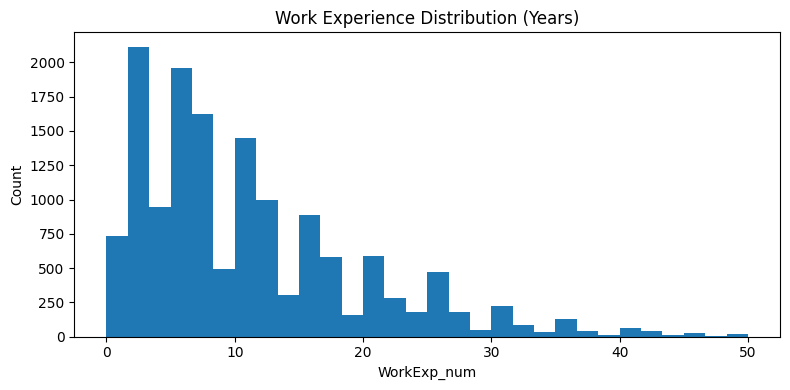

In [110]:
plt.figure(figsize=(8,4))
plt.hist(df["WorkExp_num"].dropna(), bins=30)
plt.title("Work Experience Distribution (Years)")
plt.xlabel("WorkExp_num")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_workexp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Part C — Comparisons

## C1) Salary vs AI usage (boxplot on log salary)

<Figure size 700x400 with 0 Axes>

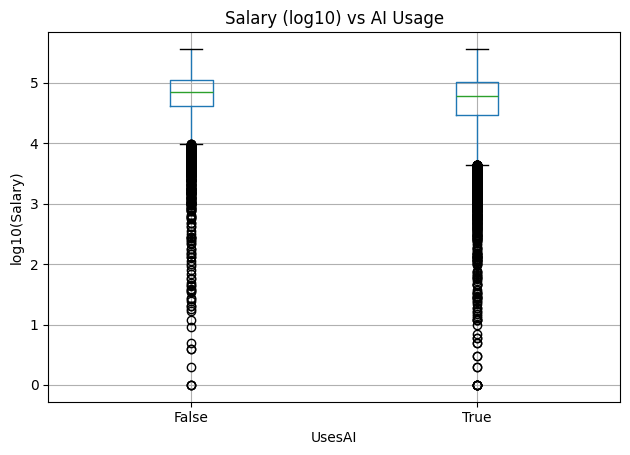

In [111]:
plt.figure(figsize=(7,4))
df.boxplot(column="Salary_log10", by="UsesAI")
plt.title("Salary (log10) vs AI Usage")
plt.suptitle("")
plt.xlabel("UsesAI")
plt.ylabel("log10(Salary)")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_salary vs ai .png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## C2) Mean vs Median salary by country (Top 5) 

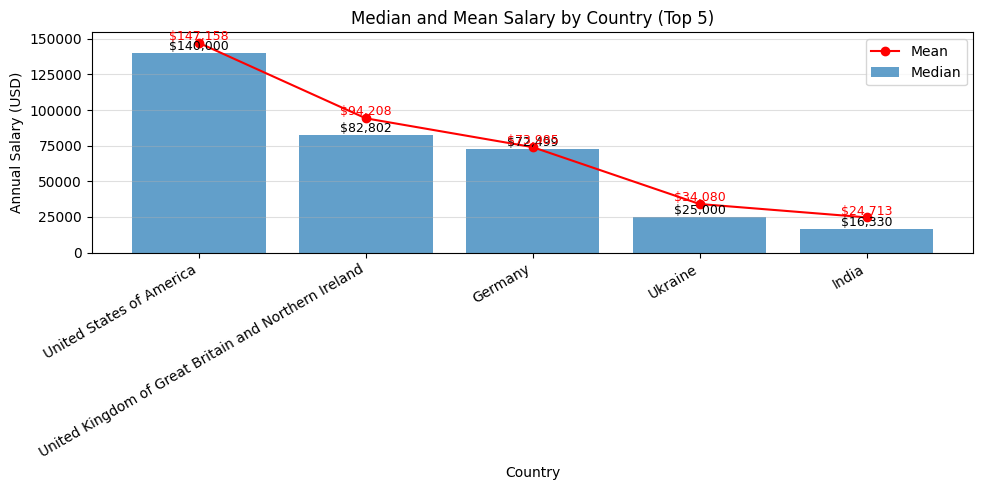

In [112]:
# --- Top 5 countries by number of respondents ---
top_countries = df["Country"].value_counts().head(5).index

df_top = df[df["Country"].isin(top_countries)]
stats = (
    df_top.groupby("Country")["ConvertedCompYearly"]
    .agg(["mean", "median"])
    .sort_values("median", ascending=False)
)
plt.figure(figsize=(10,5))
plt.bar(stats.index, stats["median"], alpha=0.7, label="Median")
plt.plot(stats.index, stats["mean"], marker="o", color="red", label="Mean")

for i, (mmean, mmed) in enumerate(zip(stats["mean"], stats["median"])):
    plt.text(i, mmed + 2000, f"${mmed:,.0f}", ha="center", fontsize=9)
    plt.text(i, mmean + 2000, f"${mmean:,.0f}", ha="center", fontsize=9, color="red")

plt.title("Median and Mean Salary by Country (Top 5)")
plt.ylabel("Annual Salary (USD)")
plt.xlabel("Country")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True, alpha=0.4, axis="y")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_salair and countries.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



## C3) Experience vs Salary (scatter) 

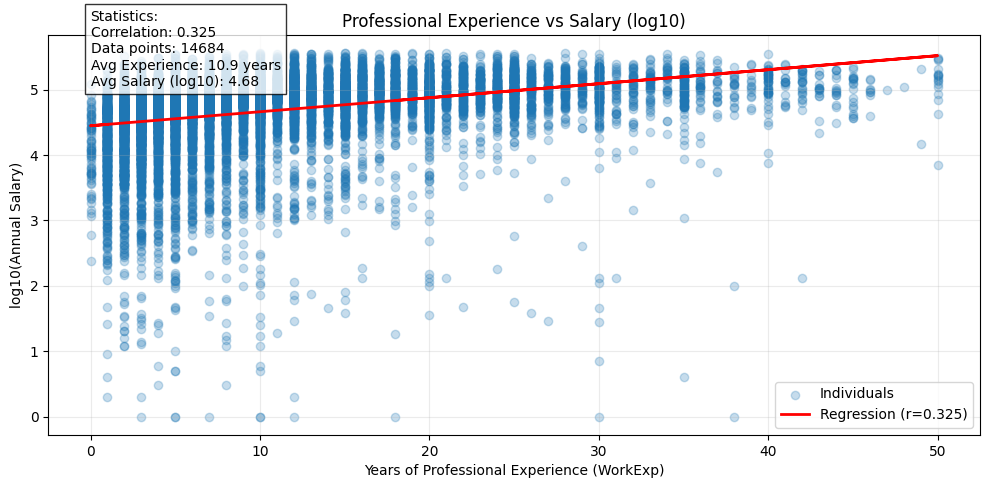

In [113]:
# --- Data ---
x = df_reg["WorkExp_num"]
y = df_reg["Salary_log10"]

# --- Regression line ---
coef = np.polyfit(x, y, 1)
line = np.poly1d(coef)

# --- Correlation ---
corr = np.corrcoef(x, y)[0, 1]

# --- Plot ---
plt.figure(figsize=(10,5))

# Scatter
plt.scatter(x, y, alpha=0.25, label="Individuals")

# Regression line
plt.plot(x, line(x), color="red", linewidth=2,
         label=f"Regression (r={corr:.3f})")

# Stats box
text = (
    f"Statistics:\n"
    f"Correlation: {corr:.3f}\n"
    f"Data points: {len(df_reg)}\n"
    f"Avg Experience: {x.mean():.1f} years\n"
    f"Avg Salary (log10): {y.mean():.2f}"
)

plt.text(x.min(), y.max()-0.5, text,
         bbox=dict(facecolor="white", alpha=0.8))

plt.title("Professional Experience vs Salary (log10)")
plt.xlabel("Years of Professional Experience (WorkExp)")
plt.ylabel("log10(Annual Salary)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_proexp vs salary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## C4) Job satisfaction vs AI usage (normalized stacked)

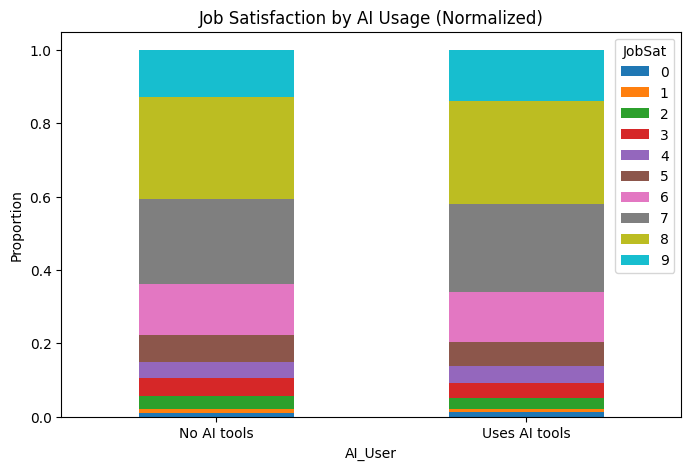

In [114]:
ct = pd.crosstab(df_js["AI_User"], df_js["JobSat"], normalize="index").reindex(columns=range(10))
ct.plot(kind="bar", stacked=True, figsize=(8,5))

plt.xticks([0,1], ["No AI tools","Uses AI tools"], rotation=0)
plt.title("Job Satisfaction by AI Usage (Normalized)")
plt.ylabel("Proportion")
plt.savefig(
    "XMJ-assets/fig_jobsat ai usage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Part D — Median salary differences across developer roles and AI tool adoption

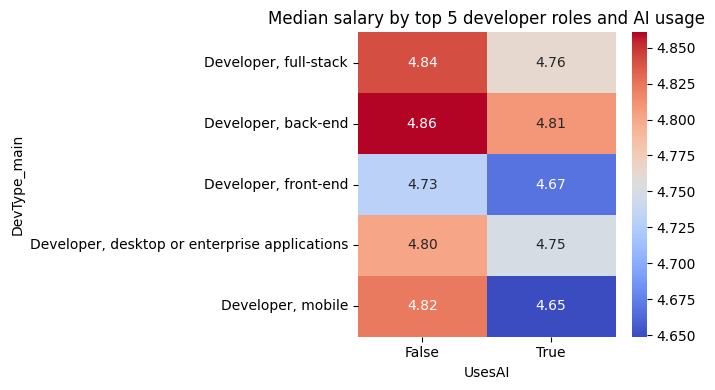

In [115]:

# 1) Top 5 developer roles (les plus fréquents)
top5_roles = df["DevType_main"].value_counts().head(5).index

df_top5 = df[df["DevType_main"].isin(top5_roles)].copy()

# 2) Pivot table (median salary) par role x UsesAI
pivot = df_top5.pivot_table(
    values="Salary_log10",
    index="DevType_main",
    columns="UsesAI",
    aggfunc="median",
    observed=True
)

# (Optionnel) ordonner l'index selon fréquence
pivot = pivot.loc[top5_roles]

# 3) Heatmap
plt.figure(figsize=(7,4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Median salary by top 5 developer roles and AI usage")
plt.tight_layout()
plt.savefig(
    "XMJ-assets/fig_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
